# Stellar population fit by ppxf — E-INSPIRE

## Import relevant modules

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import os
from os.path import basename
from copy import copy

from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

from src.ned_calculator import NedCalculator
from src.der_snr import DER_SNR
import os

## Create necessary functions

In [17]:
def bootstrap_residuals(model, resid, wild=True):
    """
    https://en.wikipedia.org/wiki/Bootstrapping_(statistics)#Resampling_residuals
    https://en.wikipedia.org/wiki/Bootstrapping_(statistics)#Wild_bootstrap

    Davidson & Flachaire (2008) eq.(12) gives the recommended form
    of the wild bootstrapping probability used here.

    https://doi.org/10.1016/j.jeconom.2008.08.003

    :param spec: model (e.g. best fitting spectrum)
    :param res: residuals (best_fit - observed)
    :param wild: use wild bootstrap to allow for variable errors
    :return: new model with bootstrapped residuals

    """
    if wild:    # Wild Bootstrapping: generates -resid or resid with prob=1/2
        eps = resid*(2*np.random.randint(2, size=resid.size) - 1)
    else:       # Standard Bootstrapping: random selection with repetition
        eps = np.random.choice(resid, size=resid.size)

    return model + eps

In [18]:
def read_fits_summary(fitsfile):
    
    hdu = fits.open(fitsfile)
    
    age_grid = hdu['age_grid'].data
    weights = hdu['pp_weights'].data.reshape(hdu['reg_dim'].data)
    
    name = hdu[0].header['name']
    z = hdu[0].header['z']
    hdu.close()
    del hdu
    
    wei1 = weights.sum(axis=1)
    wei1/=wei1.sum()
    
    wei1_rev = copy(wei1[::-1])
    
    ages = age_grid[:,0]
    ages1 = (ages[-1]-ages)[::-1]+(ages[1]-ages[0])
    
    agesplot = np.concatenate([np.array([0.]),ages1])
    weiplot = np.concatenate([np.array([0.]),np.cumsum(wei1_rev)])
    
    agesplot = np.concatenate([agesplot,np.array([agesplot[-1]+(agesplot[-1]-agesplot[-2])])])
    weiplot = np.concatenate([weiplot,np.array([weiplot[-1]])])
    
    nedcalc = NedCalculator(z)
    univ_age = nedcalc.zage_Gyr
    
    agesplot = [a if a<univ_age else univ_age for a in agesplot]
    
    return name,z,agesplot,weiplot,univ_age

In [19]:

def plot_sfh(ax,fitsfile,col_line,legend_on=False):
    
    name,z,agesplot,weiplot,univ_age = read_fits_summary(fitsfile)

    ax.set_title(name,fontsize=18,weight='bold')
    ax.set_xlim(0,13.5)
    ax.set_ylim(-0.05,1.05)
    ax.set_xlabel('Time since BB (Gyr)',fontsize=15)
    ax.set_ylabel('Cumulative mass %',fontsize=15)
    ax.minorticks_on()
    ax.tick_params(axis='both',which='both',direction='in',labelsize=15)
    
    ax.axhline(0.75,color='gray',alpha=0.2)
    ax.text(12,0.76,'75%',style='italic',color='gray')
    ax.axhline(0.95,color='gray',alpha=0.2)
    ax.text(12,0.96,'95%',style='italic',color='gray')
    ax.axvline(3.,color='gray',alpha=0.2,linestyle='-.',linewidth=2.)
    ax.axvline(univ_age,color='gray',linestyle='-.',linewidth=2.)
    
    ax.plot(agesplot,weiplot,color=col_line,linewidth=3.)
    
    ax.text(univ_age-0.1,0.,'today',color='gray',style='italic',rotation=90,horizontalalignment='right')
    ax.text(2.9,0.,'z~2',style='italic',color='gray',rotation=90,horizontalalignment='right')
    ax.set_xticks([0.,2.,4.,6.,8.,10.,12.])
    
    if legend_on==True:
        ax.legend(frameon=False,bbox_to_anchor=(univ_age/ax.get_xlim()[1], -0.05),loc='lower right',prop={'size':12,'weight':'bold'},labelspacing=0.1,labelcolor='linecolor')
        
    return agesplot,weiplot

In [20]:
def line2p(p1,p2,x):
    
    x1,y1 = p1
    x2,y2 = p2
    
    m = (y2-y1)/(x2-x1)
    q = -(y2-y1)/(x2-x1)*x1+y1
    
    return m*x+q

def line2p_rev(p1,p2,y):
    
    x1,y1 = p1
    x2,y2 = p2
    
    return (y-y1)/(y2-y1)*(x2-x1)+x1 if y2!=y1 else x2
    
def get_values_from_sfh(univ_age,sfh_table,ycol):
    '''
    INPUTS:
        univ_age: the age of the universe at the redshift of the galaxy in Gyr
        sfh_table: the plotted sfh in the form of a pandas DataFrame. It needs to have a column named "time"
        ycol: is the name of the column of the sfh_table we want to use in order to retrieve the different values we want to compute
    
    OUTPUTS:
        y_z2: mass formed at redshift~2
        x_075: time to form 75% of the mass (t_75)
        x_090: time to form 90% of the mass (t_90)
        x_100: time to form 100% of the mass (t_fin)
        dor_90: Degree of Relicness using x_090
        dor_100: : Degree of Relicness using x_100
        
    '''
    
    tt = []
    tt90 = []
    tt100 = []
    
    ii=0
    while sfh_table.iloc[ii][ycol]<0.75:
        tt.append((ii,sfh_table.iloc[ii][ycol]))
        ii+=1
    tt.append((ii,sfh_table.iloc[ii][ycol]))
    
    yy = sfh_table.iloc[np.array(tt[-2:])[:,0]]
    
    xx = line2p_rev(yy[['time',ycol]].iloc[0].values,yy[['time',ycol]].iloc[1].values,0.75)
    
    ii=0
    while sfh_table.iloc[ii][ycol]<0.9 :
        tt90.append((ii,sfh_table.iloc[ii][ycol]))
        ii+=1
    tt90.append((ii,sfh_table.iloc[ii][ycol]))
    
    yy90 = sfh_table.iloc[np.array(tt90[-2:])[:,0]]
    
    xx90 =  line2p_rev(yy90[['time',ycol]].iloc[0].values,yy90[['time',ycol]].iloc[1].values,0.9)
    
    ii=0
    while sfh_table.iloc[ii][ycol]<0.998 :
        tt100.append((ii,sfh_table.iloc[ii][ycol]))
        ii+=1
    tt100.append((ii,sfh_table.iloc[ii][ycol]))
    
    yy100 = sfh_table.iloc[np.array(tt100[-2:])[:,0]]
    
    xx100 =  line2p_rev(yy100[['time',ycol]].iloc[0].values,yy100[['time',ycol]].iloc[1].values,0.998)
    
    tt_rev = [(0,0)]
    
    for i in range(1,len(sfh_table['time'])):
        
        p1 = sfh_table['time'].iloc[i-1],sfh_table[ycol].iloc[i-1]
        p2 = sfh_table['time'].iloc[i],sfh_table[ycol].iloc[i]
        
        xs = np.arange(sfh_table['time'].iloc[i-1],sfh_table['time'].iloc[i]+0.1,0.1)
        ys = line2p(p1,p2,xs)

                
        for x,y in zip(xs,ys):
            tt_rev.append((round(x,2),y))


    tt_rev = np.array(tt_rev)

    # this is the mass formed at redshift ~2
    y_z2 = round(tt_rev[:,1][np.where(tt_rev[:,0]==2.90)[0]][0],5)
    
    # these are the times at 75%, 90%, and 100% formed mass
    x_075 = round(xx,5)
    x_090 = round(xx90,5)
    x_100 = round(xx100,5)
    
    dor_90 = (y_z2+0.5/x_075+(0.7+(univ_age-x_090)/univ_age))/3
    dor_100 = (y_z2+0.5/x_075+(0.7+(univ_age-x_100)/univ_age))/3
    
    
    
    return y_z2,x_075,x_090,x_100,dor_90,dor_100

## Load in the shortlist csv

In [21]:
from pathlib import Path
DATA_DIR = Path('../data') if Path('../data').exists() else Path('data')

# Column mapping: rename E-INSPIRE master catalogue columns to match INSPIRE names used throughout this notebook
einspire_to_inspire = {
    'GALAXY ID':        'ID_INSPIRE',
    'velDisp_ppxf_res': 'Vdisp_XSH',
    'MgFe':             'AlphaFe',
    'z':                'zspec_XSH',
}

df_in = pd.read_csv(DATA_DIR / 'E-INSPIRE_I_master_catalogue.csv')
df_in = df_in.rename(columns=einspire_to_inspire)
df_in = df_in.head(2)
df_in.head()

,ID_INSPIRE,ra,dec,plate,mjd,fiberid,objid,deVRad_r,deVRadErr_r,expRad_r,...,t_90_unr,t_90_reg,t_90_alphaplus,t_90_alphamin,t_100,t_100_unr,t_100_reg,t_100_alphaplus,t_100_alphamin,DoR
0,J2350+0609,357.704920,6.158195,4405,55854,591,1.240000e+18,0.960140,0.017636,0.924479,...,1.35128,1.39994,NaN,1.41404,10.84242,2.38420,10.84242,NaN,2.45802,0.564630
1,J1647+2956,251.955552,29.949596,1342,52793,503,1.240000e+18,0.409805,0.016891,0.548107,...,1.74192,0.78766,NaN,1.68151,10.73174,4.52743,7.34051,NaN,10.73174,0.529239


## Iterate over each row to fit the stellar population of each object

In [22]:
tie_balmer = True
limit_doublets = True

c = 299792.458  # speed of light in km/s

regul_err = 0.1 # Large regularization error

vel = 0   # eq.(8) of Cappellari (2017)

moments = [4, 2, 2]

gas_reddening = 0 if tie_balmer else None

logAges = []
metals = []
snrs = []
ids=[]

nrand = 9

col_line1 = 'black' # gdago: here you choose the color of the line        
col_line2 = 'green' # gdago: here you choose the color of the line

# Some lists to add into the catalogue later
mass_fracs = []
times_75 = []
times_90 = []
times_100 = []
dors_100 = []
univ_ages = []

mass_fracsu = []
times_75u = []
times_90u = []
times_100u = []
dors_100u = []

mass_fracsr = []
times_75r = []
times_90r = []
times_100r = []
dors_100r = []

#gal_list = ['J1438-0127', 'J2356-3332', 'J1420-0035', 'J0316-2953', 'J1412-0020'] # 'J1142+0012'
#df_in=df_in[df_in['ID_INSPIRE'].isin(gal_list)]
#print(df_in)

In [23]:
"""from astropy.io import fits

# Replace with your actual FITS file path
file_path = "../data/INSPIRE_SPEC/J0211-3155_merged_gdago_LOG.fits"


with fits.open(file_path) as hdul:
    hdul.info()
    
    # For each HDU, print detailed information about its structure
    for i, hdu in enumerate(hdul):
        print(f"\n--- HDU {i} ({hdu.name}) ---")
        if hdu.header:
            print("Header keywords:")
            for key in hdu.header:
                print(f"  {key} = {hdu.header[key]}")
        
        if hasattr(hdu, 'data') and hdu.data is not None:
            if hasattr(hdu.data, 'dtype') and hasattr(hdu.data, 'shape'):
                print(f"Data shape: {hdu.data.shape}")
                print(f"Data type: {hdu.data.dtype}")
                
                # If this is a table, show column info
                if hasattr(hdu.data, 'columns'):
                    print("Columns:")
                    for col in hdu.data.columns:
                        print(f"  {col.name}: {col.format}")"""
print("For investigating how a fits file is")

For investigating how a fits file is


In [24]:
count=0
pps=[]
savepath = 'einspire_refitting_results/'
if not os.path.exists(savepath):
    os.makedirs(savepath)

# Loop over all the galaxies in the catalogue
for index, row in df_in.iterrows():

    print(f"DOING {row['ID_INSPIRE']} NOW")

    # Construct SDSS spectrum path from plate/mjd/fiberid
    plate   = int(row['plate'])
    mjd     = int(row['mjd'])
    fiberid = int(row['fiberid'])
    spec_path = str(DATA_DIR / f'fits_shortlist/spec-{plate:04}-{mjd:05}-{fiberid:04}.fits')
    hdu = fits.open(spec_path, ignore_missing_simple=True)

    t = hdu['COADD'].data
    galaxy = t['flux'] / np.median(t['flux'])
    ln_lam_gal = t['loglam'] * np.log(10)
    wave = np.exp(ln_lam_gal)

    redshift = row['zspec_XSH']
    sigma = row['Vdisp_XSH']
    alpha = row['AlphaFe']

    if alpha < 0:
        alpha = '0'
    elif alpha > 0.4:
        alpha = '4'
    else:
        alpha = str(int(alpha*10))

    wave = wave/(1 + redshift)  # Compute wave in the galaxy rest frame
    # Restrict wavelength range
    galaxy = galaxy[(wave > 3600) & (wave < 6500)]
    wave = wave[(wave > 3600) & (wave < 6500)]

    snr = DER_SNR(galaxy) # Compute SNR
    snrs.append(snr)

    wave *= np.median(util.vac_to_air(wave)/wave)

    noise = np.full_like(galaxy, 0.0163)  # Assume constant noise per pixel here

    d_ln_lam = np.log(wave[-1]/wave[0])/(wave.size - 1)  # Average ln_lam step
    velscale = c*d_ln_lam                   # eq. (8) of Cappellari (2017)
    FWHM_gal = 2.76/(1+redshift)  # SDSS has an approximate instrumental resolution FWHM of 2.76A.

    # Load the SSP models (unrestricted MILES_SSP, not MILES_SSP_SAFE)
    filename = str(DATA_DIR / f'MILES_SSP/alpha{alpha}.npz')
    sps = lib.sps_lib(filename, velscale, FWHM_gal, age_range=[0, NedCalculator(redshift).zage_Gyr], metal_range=[-2, 0.5])

    reg_dim = sps.templates.shape[1:]
    stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)

    lam_range_gal = np.array([np.min(wave), np.max(wave)])

    gas_templates, gas_names, line_wave = util.emission_lines(
        sps.ln_lam_temp, lam_range_gal, FWHM_gal, tie_balmer=tie_balmer,
        limit_doublets=limit_doublets)

    templates = np.column_stack([stars_templates, gas_templates])

    start = [vel, sigma]     # (km/s), starting guess for [V, sigma]

    n_temps = stars_templates.shape[1]
    n_forbidden = np.sum(["[" in a for a in gas_names])  # forbidden lines contain "[*]"
    n_balmer = len(gas_names) - n_forbidden

    component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden
    gas_component = np.array(component) > 0  # gas_component=True for gas templates

    start = [start, start, start]

    # First run is just to compute a good estimate of the noise (it isn't used in the final fit)
    pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
            degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
            regul=1/regul_err, reg_dim=reg_dim, component=component,
            gas_component=gas_component, gas_names=gas_names,
            gas_reddening=gas_reddening, quiet=True)

    noise = noise*np.sqrt(pp.chi2)

    pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
                degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
                regul=1/regul_err, reg_dim=reg_dim, component=component,
                gas_component=gas_component, gas_names=gas_names,
                gas_reddening=gas_reddening, clean=True, quiet=True)

    weights = pp.weights[~gas_component]                # Exclude weights of the gas templates
    weights = weights.reshape(reg_dim)/weights.sum()    # Normalized

    mean_age = sps.mean_age_metal(weights, quiet=True)

    hdu_wei = fits.ImageHDU(data=weights,name='pp_weights') # save the grid before reshaping the weights
    hdu_regdim = fits.ImageHDU(data=reg_dim,name='reg_dim')
    hdu_age = fits.ImageHDU(data=sps.age_grid,name='age_grid')
    hdu_metal = fits.ImageHDU(data=sps.metal_grid,name='metal_grid')
    bestfit = fits.ImageHDU(data=pp.bestfit,name='bestfit_spectrum')
    lam = fits.ImageHDU(data=wave,name='wavelength')
    orig = fits.ImageHDU(data=galaxy,name='original_spectrum')
    gas = fits.ImageHDU(data=pp.gas_bestfit,name='gas_bestfit')

    name = row['ID_INSPIRE']
    z_orig = redshift
    hdr = fits.Header()
    hdr['HIERARCH NAME'] = name
    hdr['HIERARCH z'] = z_orig
    hdr['HIERARCH mean_age_unr'] = mean_age[0]
    hdr['HIERARCH mean_metal_unr'] = mean_age[1]
    hdr['HIERARCH Mg/Fe'] = row['AlphaFe']
    hdr['HIERARCH velDisp'] = row['Vdisp_XSH']
    hdr['HIERARCH SNR'] = snr
    primary_hdu = fits.PrimaryHDU(header=hdr)
    hdulist = [primary_hdu, hdu_wei, hdu_regdim, hdu_age, hdu_metal, bestfit, lam, orig, gas]
    hdulis = fits.HDUList(hdulist)
    hdulis.writeto(savepath+name+'_ppxfout_UNR.fits',overwrite=True)

    # Bootstrapping
    bestfit0 = pp.bestfit.copy()
    resid = galaxy - bestfit0
    start = pp.sol.copy()

    np.random.seed(123)

    weights_array = np.empty((nrand, pp.weights.size))
    for j in range(nrand):

        galaxy1 = bootstrap_residuals(bestfit0, resid)

        pp = ppxf(templates, galaxy1, noise, velscale, start, moments=moments,
                degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
                component=component,
                gas_component=gas_component, gas_names=gas_names,
                gas_reddening=gas_reddening, quiet=True)

        noise = noise*np.sqrt(pp.chi2)

        pp = ppxf(templates, galaxy1, noise, velscale, start, moments=moments,
                degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
                component=component,
                gas_component=gas_component, gas_names=gas_names,
                gas_reddening=gas_reddening, clean=True, quiet=True)

        weights_array[j] = pp.weights

        weights = pp.weights[~gas_component]                # Exclude weights of the gas templates
        weights = weights.reshape(reg_dim)/weights.sum()    # Normalized

    print(pp.chi2, "=CHI^2!!")
    pp.weights = weights_array.sum(0)
    pps.append(pp)
    weights_err = weights_array.std(0)

    weights = pp.weights[~gas_component]  # Exclude weights of the gas templates
    weights = weights.reshape(reg_dim)/weights.sum()  # Normalized

    mean_age = sps.mean_age_metal(weights, quiet=True)
    sps.mean_age_metal(weights, quiet=True);
    logAges.append(mean_age[0])
    metals.append(mean_age[1])

    hdu_wei = fits.ImageHDU(data=weights,name='pp_weights')
    hdu_regdim = fits.ImageHDU(data=reg_dim,name='reg_dim')
    hdu_age = fits.ImageHDU(data=sps.age_grid,name='age_grid')
    hdu_metal = fits.ImageHDU(data=sps.metal_grid,name='metal_grid')
    bestfit = fits.ImageHDU(data=pp.bestfit,name='bestfit_spectrum')
    lam = fits.ImageHDU(data=wave,name='wavelength')
    orig = fits.ImageHDU(data=galaxy,name='original_spectrum')
    gas = fits.ImageHDU(data=pp.gas_bestfit,name='gas_bestfit')

    hdr = fits.Header()
    hdr['HIERARCH NAME'] = name
    hdr['HIERARCH z'] = z_orig
    hdr['HIERARCH mean_age_unr'] = mean_age[0]
    hdr['HIERARCH mean_metal_unr'] = mean_age[1]
    hdr['HIERARCH Mg/Fe'] = row['AlphaFe']
    hdr['HIERARCH velDisp'] = row['Vdisp_XSH']
    hdr['HIERARCH SNR'] = snr
    primary_hdu = fits.PrimaryHDU(header=hdr)
    hdulist = [primary_hdu, hdu_wei, hdu_regdim, hdu_age, hdu_metal, bestfit, lam, orig, gas]
    hdulis = fits.HDUList(hdulist)
    hdulis.writeto(savepath+name+'_ppxfout_REGUL.fits',overwrite=True)

    # Plotting SFHs
    plt.figure(figsize=(6,4))
    ax1 = plt.subplot(1,1,1)
    ppxfout_file_unr = savepath + name + '_ppxfout_UNR.fits'
    ppxfout_file = savepath + name + '_ppxfout_REGUL.fits'
    agesplot,weiplot = plot_sfh(ax1,ppxfout_file_unr,col_line1,legend_on=False)
    agesplot,weiplot = plot_sfh(ax1,ppxfout_file,col_line2,legend_on=False)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.savefig(savepath+basename(ppxfout_file).replace('.fits','.pdf'),dpi=120)
    plt.close()

    # Computing DoR values
    name1,z1,agesplot1,weiplot1,univ_age1 = read_fits_summary(ppxfout_file_unr)
    name2,z2,agesplot2,weiplot2,univ_age2 = read_fits_summary(ppxfout_file)

    df_temp = pd.DataFrame({
        'time': agesplot1,
        'regul0': weiplot1,
        'regul_max': weiplot2
    })

    ids.append(name)
    y_z2u,x_075u,x_090u,x_100u,dor_90u,dor_100u = get_values_from_sfh(univ_age1,df_temp,"regul0")
    y_z2r,x_075r,x_090r,x_100r,dor_90r,dor_100r = get_values_from_sfh(univ_age2,df_temp,"regul_max")
    mass_fracsu.append(y_z2u)
    times_75u.append(x_075u)
    times_90u.append(x_090u)
    times_100u.append(x_100u)
    dors_100u.append(dor_100u)
    mass_fracsr.append(y_z2r)
    times_75r.append(x_075r)
    times_90r.append(x_090r)
    times_100r.append(x_100r)
    dors_100r.append(dor_100r)
    y_z2 = min(y_z2u,y_z2r)
    x_075 = max(x_075u,x_075r)
    x_090 = max(x_090u,x_090r)
    x_100 = max(x_100u,x_100r)
    dor_100 = (y_z2+0.5/x_075+(0.7+(univ_age1-x_100))/univ_age1)/3
    mass_fracs.append(y_z2)
    times_75.append(x_075)
    times_90.append(x_090)
    times_100.append(x_100)
    dors_100.append(dor_100)
    univ_ages.append(univ_age1)
    count+=1
    print(f'Galaxy {count}/{len(df_in)} done')

DOING J2350+0609 NOW
Emission lines included in gas templates:
['Balmer' '[OII]3726_d1' '[OII]3726_d2' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d']


KeyboardInterrupt: 

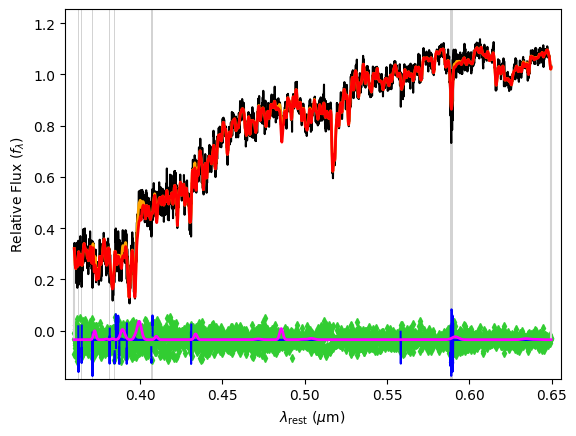

In [ ]:
pps[0].plot()

## Save everything

In [ ]:
df_out = pd.DataFrame()
df_out['ID_INSPIRE'] = ids
df_out['logAge'] = logAges
df_out['[M/H]'] = metals
df_out['SNR'] = snrs

df_out['mass_frac'] = mass_fracs
df_out['time_75'] = times_75
df_out['time_90'] = times_90
df_out['time_100'] = times_100
df_out['dor_100'] = dors_100
df_out['univ_age'] = univ_ages

df_out['mass_frac_reg'] = mass_fracsr
df_out['time_75_reg'] = times_75r
df_out['time_90_reg'] = times_90r
df_out['time_100_reg'] = times_100r
df_out['dor_100_reg'] = dors_100r

df_out['mass_frac_unr'] = mass_fracsu
df_out['time_75_unr'] = times_75u
df_out['time_90_unr'] = times_90u
df_out['time_100_unr'] = times_100u
df_out['dor_100_unr'] = dors_100u

df_out.head()

,ID_INSPIRE,logAge,[M/H],SNR,mass_frac,time_75,time_90,time_100,dor_100,univ_age,mass_frac_reg,time_75_reg,time_90_reg,time_100_reg,dor_100_reg,mass_frac_unr,time_75_unr,time_90_unr,time_100_unr,dor_100_unr
0,J2350+0609,10.031052,0.338573,34.772045,0.95977,1.05552,2.30408,10.26382,0.542665,11.873500,0.95977,1.05552,2.30408,10.26382,0.756346,0.99837,0.88559,1.27726,2.28082,1.023624
1,J1647+2956,10.025548,0.254247,19.235961,0.95915,1.19495,1.74517,8.60648,0.559336,11.301923,0.95915,0.48890,1.35270,8.60648,0.973449,0.97756,1.19495,1.74517,5.13534,0.880537


In [ ]:
df_out.to_csv('einspire_refitting_results/output.csv', index=False)

In [ ]:
print(df_out)

   ID_INSPIRE     logAge     [M/H]        SNR  mass_frac  time_75  time_90  \
0  J2350+0609  10.031052  0.338573  34.772045    0.95977  1.05552  2.30408   
1  J1647+2956  10.025548  0.254247  19.235961    0.95915  1.19495  1.74517   

   time_100   dor_100   univ_age  mass_frac_reg  time_75_reg  time_90_reg  \
0  10.26382  0.542665  11.873500        0.95977      1.05552      2.30408   
1   8.60648  0.559336  11.301923        0.95915      0.48890      1.35270   

   time_100_reg  dor_100_reg  mass_frac_unr  time_75_unr  time_90_unr  \
0      10.26382     0.756346        0.99837      0.88559      1.27726   
1       8.60648     0.973449        0.97756      1.19495      1.74517   

   time_100_unr  dor_100_unr  
0       2.28082     1.023624  
1       5.13534     0.880537  


## Compute everything for alpha/Fe±0.1

In [ ]:
tie_balmer = True
limit_doublets = True

c = 299792.458  # speed of light in km/s

regul_err = 0.1 # Large regularization error

vel = 0   # eq.(8) of Cappellari (2017)

moments = [4, 2, 2]

gas_reddening = 0 if tie_balmer else None

logAges = []
metals = []
snrs = []

In [ ]:
"""# Same logic as before but no bootstrapping
for index, row in df_out.iterrows():

    plate = row['plate']
    mjd = row['mjd']
    fiberid = row['fiberid']
    txt_name = '/spec-' + f'{plate:04}' + '-' + f'{mjd:05}' + '-' + f'{fiberid:04}' + '.fits'

    hdu = fits.open('/Users/johnmills/Summer project/alpha_calculator/fits_shortlist' + txt_name, ignore_missing_simple=True)
    t = hdu['COADD'].data

    galaxy = t['flux']/np.median(t['flux'])     # Normalize spectrum to avoid numerical issues
    ln_lam_gal = t['loglam']*np.log(10)         # Convert lg --> ln
    wave0 = np.exp(ln_lam_gal)

    redshift = row['z']
    sigma = row['velDisp_ppxf']
    alpha_orig = row['alpha']

    wave = wave0/(1 + redshift)  # Compute wave in the galaxy rest frame
    galaxy = galaxy[(wave > 3600) & (wave < 6500)]
    wave = wave[(wave > 3600) & (wave < 6500)]

    # # alpha + 0.1
    if alpha_orig < 0.4:
        alpha = alpha_orig + 0.1

        if alpha_orig == 0 and row['alpha_flag'] == -1:
            alpha = 0.4

        alpha = str(int(alpha*10))

        snr = DER_SNR(galaxy)
        snrs.append(snr)

        wave *= np.median(util.vac_to_air(wave)/wave)

        noise = np.full_like(galaxy, 0.0163)  # Assume constant noise per pixel here

        d_ln_lam = np.log(wave[-1]/wave[0])/(wave.size - 1)  # Average ln_lam step
        velscale = c*d_ln_lam                   # eq. (8) of Cappellari (2017)
        FWHM_gal = 2.76/(1+redshift)  # SDSS has an approximate instrumental resolution FWHM of 2.76A.

        # filename = f'/Users/johnmills/Summer project/MILES_SSP/alpha{alpha}.npz'
        sps = lib.sps_lib(filename, velscale, FWHM_gal, age_range=[0, NedCalculator([redshift]).zage_Gyr], metal_range=[-2, 0.5])

        reg_dim = sps.templates.shape[1:]
        stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)

        lam_range_gal = np.array([np.min(wave), np.max(wave)])

        gas_templates, gas_names, line_wave = util.emission_lines(
            sps.ln_lam_temp, lam_range_gal, FWHM_gal, tie_balmer=tie_balmer,
            limit_doublets=limit_doublets)
        
        templates = np.column_stack([stars_templates, gas_templates])

        start = [vel, sigma]     # (km/s), starting guess for [V, sigma]

        n_temps = stars_templates.shape[1]
        n_forbidden = np.sum(["[" in a for a in gas_names])  # forbidden lines contain "[*]"
        n_balmer = len(gas_names) - n_forbidden

        component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden
        gas_component = np.array(component) > 0  # gas_component=True for gas templates

        start = [start, start, start]

        pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
            degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
            regul=1/regul_err, reg_dim=reg_dim, component=component,
            gas_component=gas_component, gas_names=gas_names,
            gas_reddening=gas_reddening, quiet=True)

        noise = noise*np.sqrt(pp.chi2)

        pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
                    degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
                    regul=1/regul_err, reg_dim=reg_dim, component=component,
                    gas_component=gas_component, gas_names=gas_names,
                    gas_reddening=gas_reddening, clean=True, quiet=True)
        
        weights = pp.weights[~gas_component]                # Exclude weights of the gas templates
        weights = weights.reshape(reg_dim)/weights.sum()    # Normalized

        mean_age = sps.mean_age_metal(weights, quiet=True)

        hdu_wei = fits.ImageHDU(data=weights,name='pp_weights') # save the grid before reshaping the weights
        hdu_regdim = fits.ImageHDU(data=reg_dim,name='reg_dim')
        hdu_age = fits.ImageHDU(data=sps.age_grid,name='age_grid')
        hdu_metal = fits.ImageHDU(data=sps.metal_grid,name='metal_grid')
        bestfit = fits.ImageHDU(data=pp.bestfit,name='bestfit_spectrum')
        lam = fits.ImageHDU(data=wave,name='wavelength')
        orig = fits.ImageHDU(data=galaxy,name='original_spectrum')
        gas = fits.ImageHDU(data=pp.gas_bestfit,name='gas_bestfit')

        #Store the results in a way that is suitable for Peppe's SFH plotting
        name = row['sexa_id'] #This is just the ID
        z_orig = redshift # This should be the original redshift of each galaxy
        # Write outputs in fits files
        hdr = fits.Header()
        hdr['HIERARCH SDSS_ID'] = row['objid']
        hdr['HIERARCH NAME'] = name
        hdr['HIERARCH z'] = z_orig
        hdr['HIERARCH mean_age_unr'] = mean_age[0]
        hdr['HIERARCH mean_metal_unr'] = mean_age[1]
        hdr['HIERARCH Mg/Fe'] = row['alpha']
        hdr['HIERARCH velDisp'] = row['velDisp_ppxf']
        hdr['HIERARCH SNR'] = snr
        primary_hdu = fits.PrimaryHDU(header=hdr)
        hdulist = [primary_hdu, hdu_wei, hdu_regdim, hdu_age, hdu_metal, bestfit, lam, orig, gas]
        hdulis = fits.HDUList(hdulist)
        savepath = 'refitting_results/'
        if not os.path.exists(savepath):
            os.makedirs(savepath)
        hdulis.writeto(savepath+name+'_ppxfout_plus.fits',overwrite=True)

    # alpha - 0.1
    if alpha_orig > 0:
        alpha = alpha_orig - 0.1

        if alpha_orig == 0.4 and row['alpha_flag'] == 1:
            alpha = 0.

        alpha = str(int(alpha*10))

        snr = DER_SNR(galaxy)
        snrs.append(snr)

        wave *= np.median(util.vac_to_air(wave)/wave)

        noise = np.full_like(galaxy, 0.0163)

        d_ln_lam = np.log(wave[-1]/wave[0])/(wave.size - 1)
        velscale = c*d_ln_lam
        FWHM_gal = 2.76/(1+redshift)

        filename = f'../data/MILES_SSP_SAFE/alpha{alpha}.npz'

        sps = lib.sps_lib(filename, velscale, FWHM_gal, age_range=[0, NedCalculator([redshift]).zage_Gyr], metal_range=[-2, 0.5])

        reg_dim = sps.templates.shape[1:]
        stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)

        lam_range_gal = np.array([np.min(wave), np.max(wave)])

        gas_templates, gas_names, line_wave = util.emission_lines(
            sps.ln_lam_temp, lam_range_gal, FWHM_gal, tie_balmer=tie_balmer,
            limit_doublets=limit_doublets)
        
        templates = np.column_stack([stars_templates, gas_templates])

        start = [vel, sigma]

        n_temps = stars_templates.shape[1]
        n_forbidden = np.sum(["[" in a for a in gas_names])
        n_balmer = len(gas_names) - n_forbidden

        component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden
        gas_component = np.array(component) > 0

        start = [start, start, start]

        pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
            degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
            regul=1/regul_err, reg_dim=reg_dim, component=component,
            gas_component=gas_component, gas_names=gas_names,
            gas_reddening=gas_reddening, quiet=True)

        noise = noise*np.sqrt(pp.chi2)

        pp = ppxf(templates, galaxy, noise, velscale, start, moments=moments,
                    degree=-1, mdegree=8, lam=wave, lam_temp=sps.lam_temp,
                    regul=1/regul_err, reg_dim=reg_dim, component=component,
                    gas_component=gas_component, gas_names=gas_names,
                    gas_reddening=gas_reddening, clean=True, quiet=True)
        
        weights = pp.weights[~gas_component]                # Exclude weights of the gas templates
        weights = weights.reshape(reg_dim)/weights.sum()    # Normalized

        mean_age = sps.mean_age_metal(weights, quiet=True)

        hdu_wei = fits.ImageHDU(data=weights,name='pp_weights') # save the grid before reshaping the weights
        hdu_regdim = fits.ImageHDU(data=reg_dim,name='reg_dim')
        hdu_age = fits.ImageHDU(data=sps.age_grid,name='age_grid')
        hdu_metal = fits.ImageHDU(data=sps.metal_grid,name='metal_grid')
        bestfit = fits.ImageHDU(data=pp.bestfit,name='bestfit_spectrum')
        lam = fits.ImageHDU(data=wave,name='wavelength')
        orig = fits.ImageHDU(data=galaxy,name='original_spectrum')
        gas = fits.ImageHDU(data=pp.gas_bestfit,name='gas_bestfit')

        #Store the results in a way that is suitable for Peppe's SFH plotting
        name = row['sexa_id'] #This is just the ID
        z_orig = redshift # This should be the original redshift of each galaxy
        # Write outputs in fits files
        hdr = fits.Header()
        hdr['HIERARCH SDSS_ID'] = row['objid']
        hdr['HIERARCH NAME'] = name
        hdr['HIERARCH z'] = z_orig
        hdr['HIERARCH mean_age_unr'] = mean_age[0]
        hdr['HIERARCH mean_metal_unr'] = mean_age[1]
        hdr['HIERARCH Mg/Fe'] = row['alpha']
        hdr['HIERARCH velDisp'] = row['velDisp_ppxf']
        hdr['HIERARCH SNR'] = snr
        primary_hdu = fits.PrimaryHDU(header=hdr)
        hdulist = [primary_hdu, hdu_wei, hdu_regdim, hdu_age, hdu_metal, bestfit, lam, orig, gas]
        hdulis = fits.HDUList(hdulist)
        savepath = './ppxf_fits_test2/'
        if not os.path.exists(savepath):
            os.makedirs(savepath)
        hdulis.writeto(savepath+name+'_ppxfout_minus.fits',overwrite=True)

    print(f'Galaxy {index} done')
"""
print("SKIPPPPPP")

SKIPPPPPP
